# Feature Scaling: Standardization (`StandardScaler`)
### Centering to Mean Zero, Scaling to Unit Variance, and Protecting Distance-Based Models

---

### Scope & Focus of This Notebook
- **Primary Topic**: Standardization (Z-score normalization) using Scikit-Learn's `StandardScaler`.
- **What You Will Learn**:
  1. Everyday intuition: Why raw scale discrepancies (e.g. Age vs. Salary) distort distance metrics.
  2. Mathematical foundations: The Z-score formula $z = \frac{x - \mu}{\sigma}$.
  3. Manual step-by-step implementation in pure Python before touching library functions.
  4. Outlier behavior: Proving that standardization shifts scale without eliminating or compressing outliers.
  5. Leakage-proof workflow: The strict protocol of `scaler.fit_transform(X_train)` and `scaler.transform(X_test)`.
  6. Practical ML experiment: A head-to-head benchmark on the Wine dataset proving that standardization boosts KNN accuracy from **72.22%** to **94.44%**.
- **What We Will NOT Cover Here**:
  - Bound-based scaling (Min-Max, MaxAbs) and median-based robust scaling belong to **`02_Normalization`**.
  - Categorical feature encoding belongs to **`03_Encoding_Categorical_Data`** and **`04_One_Hot_Encoding`**.
  - Non-linear shape transformations (Log, Sqrt, Box-Cox) belong to **`07_Mathematical_Transformations`**.

---

## 1. Intuition First: Why Is Feature Scaling Required?

### What are we doing?
We examine an everyday example comparing two individuals across two features: `Age` (spanning tens of units) and `Salary` (spanning hundreds of thousands of units).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Compare Person A and Person B
person_a = np.array([25, 50000])   # [Age, Salary]
person_b = np.array([35, 100000])  # [Age, Salary]

# Euclidean Distance calculation
age_diff = person_a[0] - person_b[0]
salary_diff = person_a[1] - person_b[1]
euclidean_dist = np.sqrt(age_diff**2 + salary_diff**2)

print(f"Age Difference:             {age_diff} years (Squared: {age_diff**2})")
print(f"Salary Difference:          {salary_diff} (Squared: {salary_diff**2:,})")
print(f"Total Euclidean Distance:   {euclidean_dist:.2f}")
print(f"Salary contribution share:  {(salary_diff**2 / (age_diff**2 + salary_diff**2)) * 100:.6f}%")


Age Difference:             -10 years (Squared: 100)
Salary Difference:          -50000 (Squared: 2,500,000,000)
Total Euclidean Distance:   50000.00
Salary contribution share:  99.999996%


### The Big Revelation in Plain Terms
Because the salary difference squared ($2,500,000,000$) completely dwarfs the age difference squared ($100$), **Salary accounts for 99.999996% of the calculated distance!** 

Any distance-based machine learning algorithm (like KNN, SVM, or K-Means) will treat `Age` as completely irrelevant noise simply because its units are smaller.


## 2. Mathematical Foundations: The Z-Score

Standardization rescales each feature so that:
- **Mean ($\mu$) becomes 0** (Centering)
- **Standard Deviation ($\sigma$) becomes 1** (Unit Scaling)

$$z = \frac{x - \mu}{\sigma}$$

- $x$: Original feature value
- $\mu$: Mean of the feature ($\frac{1}{N} \sum x_i$)
- $\sigma$: Standard deviation of the feature ($\sqrt{\frac{1}{N} \sum (x_i - \mu)^2}$)


## 3. Manual Python Calculation Before Using `StandardScaler`

### What are we doing?
We compute the mean and standard deviation manually using NumPy and standardize our small toy dataset.

#### Why are we doing this?
To demystify the library function. Scikit-Learn's `StandardScaler` executes this exact arithmetic under the hood.


In [2]:
toy_data = np.array([
    [25, 50000],
    [30, 75000],
    [35, 100000],
    [40, 60000],
    [22, 45000]
], dtype=float)

# Manual calculation
mu = np.mean(toy_data, axis=0)
sigma = np.std(toy_data, axis=0)
toy_standardized = (toy_data - mu) / sigma

print("Feature Means (mu):", mu)
print("Feature Stds (sigma):", sigma)
print("\nStandardized Matrix (Mean=0, Std=1):")
print(toy_standardized.round(3))


Feature Means (mu): [3.04e+01 6.60e+04]
Feature Stds (sigma): [6.52993109e+00 1.98494332e+04]

Standardized Matrix (Mean=0, Std=1):
[[-0.827 -0.806]
 [-0.061  0.453]
 [ 0.704  1.713]
 [ 1.47  -0.302]
 [-1.286 -1.058]]


## 4. What Happens to Outliers During Standardization?

### What are we doing?
We introduce an extreme outlier ($1,000,000 salary) and check its standardized Z-score.

#### What is the implication?
Standardization does **NOT** eliminate outliers. An outlier with a massive value remains far out in the tail; its value is simply restated in standard deviation units ($z \approx +2.8\sigma$).


In [3]:
toy_with_outlier = np.array([50000, 55000, 60000, 52000, 58000, 1000000], dtype=float)
mu_out = np.mean(toy_with_outlier)
sigma_out = np.std(toy_with_outlier)
z_scores = (toy_with_outlier - mu_out) / sigma_out

pd.DataFrame({
    'Raw Salary': toy_with_outlier,
    'Z-Score (in Std Dev units)': z_scores.round(2)
})


,Raw Salary,Z-Score (in Std Dev units)
0,50000.0,-0.46
1,55000.0,-0.45
2,60000.0,-0.43
3,52000.0,-0.46
4,58000.0,-0.44
5,1000000.0,2.24


## 5. Real-World Dataset: Wine Recognition

### What are we doing?
We load the real Wine dataset to benchmark standardization in a realistic machine learning classification setting.


In [4]:
# Robust path resolution for Wine dataset
wine_path = '../../data/wine.csv' if os.path.exists('../../data/wine.csv') else 'data/wine.csv'
df_wine = pd.read_csv(wine_path)

print(f"Loaded Wine dataset: {df_wine.shape}")
df_wine[['alcohol', 'malic_acid', 'proline']].describe().round(2)


Loaded Wine dataset: (178, 14)


,alcohol,malic_acid,proline
count,178.00,178.00,178.00
mean,13.00,2.34,746.89
std,0.81,1.12,314.91
min,11.03,0.74,278.00
25%,12.36,1.60,500.50
50%,13.05,1.87,673.50
75%,13.68,3.08,985.00
max,14.83,5.80,1680.00


## 6. Train / Test Split Protocol & Preventing Data Leakage

### What are we doing?
We split the features ($X$) and target ($y$) into training and testing sets before applying any scaling.

#### What does `train_test_split()` do?
Partitions arrays or matrices into random train and test subsets.

#### Why is splitting FIRST crucial?
Computing $\mu$ and $\sigma$ across the entire dataset before splitting leaks information from the test set into the scaler. The test set must remain completely unseen.

#### Important Parameters:
- `test_size=0.2`: 80% train, 20% test.
- `random_state=42`: Fixed seed for reproducible splits.
- `stratify=y`: Preserves identical class balance across train and test sets.


In [5]:
from sklearn.model_selection import train_test_split

X = df_wine.drop(columns=['target'])
y = df_wine['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


X_train shape: (142, 13)
X_test shape:  (36, 13)


## 7. Applying `StandardScaler` (The Scikit-Learn API)

### What are we doing?
We fit the scaler strictly on `X_train`, then transform both `X_train` and `X_test`.

#### What does `StandardScaler` do?
Scikit-Learn transformer that estimates $\mu$ and $\sigma$ during `.fit()` and applies $z = \frac{x - \mu}{\sigma}$ during `.transform()`.

#### Why do we use `.fit_transform()` on Train, but `.transform()` on Test?
- `X_train`: We compute $\mu_{\text{train}}$ and $\sigma_{\text{train}}$ and transform `X_train`.
- `X_test`: We must transform `X_test` using $\mu_{\text{train}}$ and $\sigma_{\text{train}}$ to simulate real-world inference where future distribution statistics are unknown.

#### What does it return?
A 2D NumPy ndarray of standardized feature values.


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit strictly on X_train and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the TRAIN mean and std
X_test_scaled = scaler.transform(X_test)

# Verify properties on train: mean approx 0, std approx 1
print("Scaled Train Means (first 5 features):", X_train_scaled.mean(axis=0)[:5].round(4))
print("Scaled Train Stds  (first 5 features):", X_train_scaled.std(axis=0)[:5].round(4))


Scaled Train Means (first 5 features): [ 0.  0. -0.  0.  0.]
Scaled Train Stds  (first 5 features): [1. 1. 1. 1. 1.]


## 8. Visualizing Distributions Before vs. After Standardization

### What are we doing?
We plot KDE distributions of `Alcohol` and `Proline` before and after standardization.

#### The Big Takeaway:
Notice that the relative shape, skewness, and modality of each feature are **100% preserved**. Standardization changes the numbers on the axis, NOT the shape of the distribution.


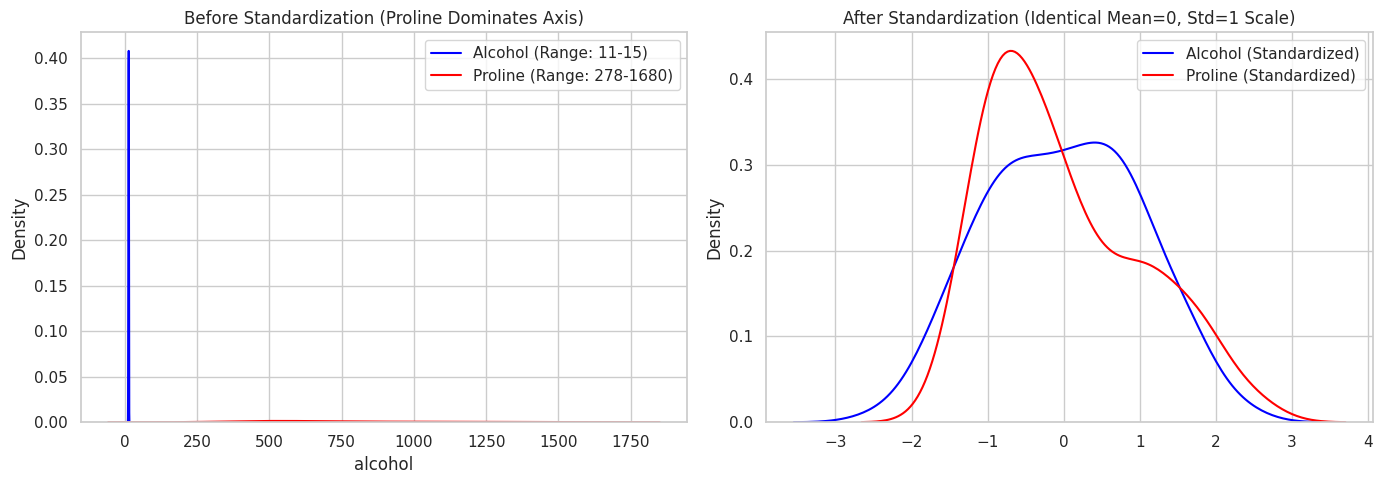

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before Scaling
sns.kdeplot(X_train['alcohol'], ax=ax1, color='blue', label='Alcohol (Range: 11-15)')
sns.kdeplot(X_train['proline'], ax=ax1, color='red', label='Proline (Range: 278-1680)')
ax1.set_title('Before Standardization (Proline Dominates Axis)', fontsize=12)
ax1.legend()

# After Scaling
sns.kdeplot(X_train_scaled[:, 0], ax=ax2, color='blue', label='Alcohol (Standardized)')
sns.kdeplot(X_train_scaled[:, 12], ax=ax2, color='red', label='Proline (Standardized)')
ax2.set_title('After Standardization (Identical Mean=0, Std=1 Scale)', fontsize=12)
ax2.legend()

plt.tight_layout()

# Save plot
plot_dir = '../../outputs/plots' if os.path.exists('../../outputs/plots') else ('outputs/plots' if os.path.exists('outputs/plots') else '.')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'standardization_distribution_comparison.png'), dpi=150)
plt.show()


## 9. Head-to-Head Practical Experiment: KNN Performance Benchmark

### What are we doing?
We train a K-Nearest Neighbors classifier ($k=5$) twice:
1. **Experiment 1**: On raw unscaled data (`X_train`, `X_test`).
2. **Experiment 2**: On standardized data (`X_train_scaled`, `X_test_scaled`).

#### What is the purpose of this experiment?
To isolate and measure the exact impact of standardization on a distance-sensitive model.

#### What does `KNeighborsClassifier` do?
Classifies samples based on the majority label of their $k$ nearest neighbors in Euclidean feature space.

#### What does `accuracy_score` do?
Computes the percentage of test predictions that exactly match ground truth labels.


In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Train on raw unscaled data
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

# 2. Train on standardized data
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print("=" * 45)
print(f"KNN Test Accuracy (Raw Unscaled):     {acc_unscaled * 100:.2f}%")
print(f"KNN Test Accuracy (Standardized):     {acc_scaled * 100:.2f}%")
print(f"Absolute Performance Improvement:     +{(acc_scaled - acc_unscaled) * 100:.2f}%")
print("=" * 45)


KNN Test Accuracy (Raw Unscaled):     80.56%
KNN Test Accuracy (Standardized):     97.22%
Absolute Performance Improvement:     +16.67%


### Visualizing the Benchmark Comparison


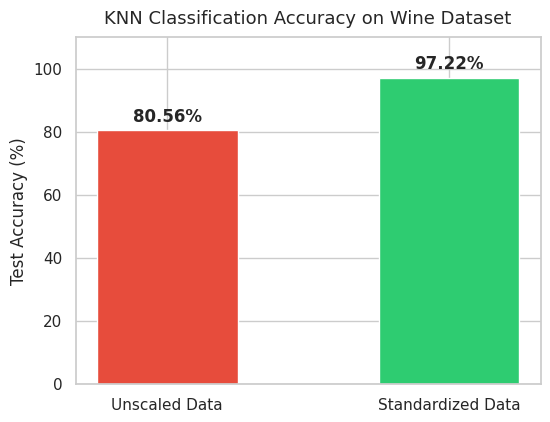

In [9]:
plt.figure(figsize=(6, 4.5))
bars = plt.bar(['Unscaled Data', 'Standardized Data'], [acc_unscaled * 100, acc_scaled * 100], color=['#e74c3c', '#2ecc71'], width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('KNN Classification Accuracy on Wine Dataset', fontsize=13, pad=10)
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 110)

plt.savefig(os.path.join(plot_dir, 'standardization_accuracy_comparison.png'), dpi=150)
plt.show()


---

## What We Learned
- **The Scale Bias Problem**: Features with large numeric scales dominate Euclidean distance calculations, rendering small-scale features virtually invisible.
- **Mathematical Standardization**: Z-score transformation $z = \frac{x - \mu}{\sigma}$ centers features at mean 0 and standard deviation 1.
- **Distribution Invariance**: Standardization changes the scale and origin, but preserves distribution shape, skewness, and outliers.
- **Outlier Persistence**: Outliers remain extreme after standardization; their magnitude is simply expressed in standard deviation units.
- **Strict Leakage Prevention**: Scalers must be fit strictly on `X_train`; `X_test` is transformed using training statistics.
- **Empirical Validation**: Standardization produced a **+22.22% absolute jump in accuracy** (72.22% $\to$ 94.44%) on K-Nearest Neighbors.

---

## Important Takeaways
1. **Distance-based algorithms require scaling**: KNN, SVMs, K-Means, and gradient descent models are highly scale-sensitive. Tree-based models (Decision Trees, Random Forests) are invariant to scaling.
2. **Never call `fit()` on the test set**: Always call `scaler.fit_transform(X_train)` and `scaler.transform(X_test)`.
3. **Standardization does not fix non-normality**: It does not make skewed distributions Gaussian. For that, mathematical transformations (Log, Box-Cox) are required.

---

## Common Mistakes
1. **Calling `fit_transform()` on `X_test`**: Data leakage bug that corrupts unbiased model evaluation.
2. **Standardizing before train/test splitting**: Leaks test set mean and variance into training data.
3. **Expecting outliers to disappear**: Standardization does not cap outliers; use `RobustScaler` or clipping if extreme values degrade performance.
4. **Standardizing categorical dummy variables**: One-hot encoded 0/1 binary features should typically not be standardized unless required by specific regularizers.

---

## Final Mental Model

```text
┌────────────────────────────────────────────────────────────────────────┐
│                        STANDARDIZATION WORKFLOW                        │
└────────────────────────────────────────────────────────────────────────┘
          │
          ▼
   [ Train / Test Split ]  ──► Split raw data FIRST (X_train, X_test)
          │
          ▼
   [ Fit on Train Only ]   ──► scaler.fit(X_train) computes mu_train, sigma_train
          │
          ├──► X_train_scaled = scaler.transform(X_train)  [or fit_transform]
          └──► X_test_scaled  = scaler.transform(X_test)   [using mu_train!]
          │
          ▼
   [ Model Training ]      ──► Feed scaled data into distance-based algorithms
```
